In [36]:
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely.geometry as sgeo
import time
import plotly.express as px
import requests


In [37]:
reference_path = "../../../results/road/freeflow/reference_survey.parquet"

tomtom_key_path = "../../../resources/tomtom_api_key"
with open(tomtom_key_path) as f:
    tomtom_api_key = f.read()
    
matsim_routing_endpoint = "http://localhost:8054/router/road"
matsim_departure_time = 4 * 3600
matsim_batch_size = 10


In [38]:
# Load reference
df_reference = pd.read_parquet(reference_path)
df_reference

,trip_id,origin_x,origin_y,destination_x,destination_y,reference_travel_time_s,departure_time,weight,euclidean_distance,computed_distance,distance_error,departure_hour
48,291,841816.338227,6.517617e+06,834710.59,6544287.03,1800.0,18000.0,50.09030,28470,27600.764510,869.235490,5.0
96,649,841932.840000,6.518717e+06,846049.94,6493021.53,1500.0,19800.0,86.56719,26410,26022.898492,387.101508,5.0
262,1993,842750.000000,6.513150e+06,842566.37,6520215.29,2100.0,15600.0,55.81574,6810,7067.675909,257.675909,4.0
300,2432,843756.235414,6.518757e+06,842549.45,6520525.48,900.0,99000.0,44.86339,2080,2141.355221,61.355221,3.0
301,2439,843632.331640,6.518450e+06,842549.49,6520453.39,900.0,99000.0,44.86339,2080,2276.947072,196.947072,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
39160,97998,877724.859383,6.538873e+06,879065.08,6544503.85,720.0,18000.0,126.02200,4610,5788.157201,1178.157201,5.0
39201,98091,870773.448504,6.522307e+06,861217.74,6515679.87,1500.0,19500.0,55.23756,12660,11629.027064,1030.972936,5.0
39421,98499,879761.190852,6.548801e+06,880933.82,6542827.07,600.0,21000.0,169.53970,5030,6088.398387,1058.398387,5.0
39426,98504,882587.611534,6.547934e+06,879748.39,6544802.98,300.0,19800.0,132.06210,5610,4226.835270,1383.164730,5.0


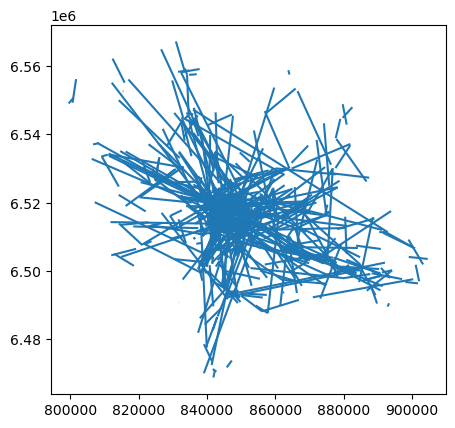

In [39]:
# Sample a few trip
nb_samples = None
if nb_samples is None:
    df_reference_samples = df_reference
else:
    df_reference_samples = df_reference.sample(n=nb_samples, random_state=42)
df_reference_samples
df_reference_samples["origin"] = gpd.points_from_xy(df_reference_samples["origin_x"], df_reference_samples["origin_y"])
df_reference_samples["destination"] = gpd.points_from_xy(df_reference_samples["destination_x"], df_reference_samples["destination_y"])
df_reference_samples["geometry"] = df_reference_samples[["origin", "destination"]].apply(
    lambda row: sgeo.LineString([row["origin"], row["destination"]]),
    axis=1
)
gdf_reference_samples = gpd.GeoDataFrame(
    df_reference_samples,
    geometry="geometry",
    crs="EPSG:2154"
)
gdf_reference_samples.plot()
gdf_reference_samples.drop(columns=["origin", "destination"], inplace=True)

In [40]:
# Convert to WGS
df_reference_samples["geometry"] = [
    sgeo.LineString([
        sgeo.Point(ox, oy), sgeo.Point(dx, dy)
    ])
    for ox, oy, dx, dy in zip(
        df_reference_samples["origin_x"], df_reference_samples["origin_y"],
        df_reference_samples["destination_x"], df_reference_samples["destination_y"]
    )
]

df_reference_samples_latlong = gpd.GeoDataFrame(df_reference_samples, crs = "EPSG:2154")
df_reference_samples_latlong = df_reference_samples_latlong.to_crs("EPSG:4326")


In [41]:
# Convert to list of requests
tomtom_request_list = [{
    "trip_id": row["trip_id"],
    "origin": "{},{}".format(*row["geometry"].coords[0][::-1]),
    "destination": "{},{}".format(*row["geometry"].coords[1][::-1]),
} for index, row in df_reference_samples_latlong.iterrows()]

In [42]:
tomtom_response_list = []
tomtom_request_slack = 0.5
tomtom_batch_points_size = 40

print("number of requests", len(range(0, len(tomtom_request_list), tomtom_batch_points_size)))
batched_requests = [tomtom_request_list[batch_start:batch_start + tomtom_batch_points_size] for batch_start in range(0, len(tomtom_request_list), tomtom_batch_points_size)]

for batch in batched_requests:

    batch_points = []
    for request in batch:
        batch_points.append("%s:%s" % (request["origin"], request["destination"]))
    batch_trip_ids = [request["trip_id"] for request in batch]

    response = requests.get(
        "https://api.tomtom.com/routing/1/calculateRoute/{}/json".format(":".join(batch_points)),
        {
            "departAt": "2025-08-01T10:00:00",
            "routeType": "fastest",
            "traffic": "true",
            "computeTravelTimeFor": "all",
            "key": tomtom_api_key
        }
    )

    if response.status_code != 200:
        if response.status_code == 400:
            print("Bad request for:", response.status_code, response.content)
        else:
            print("Error code:", response.status_code, response.content)
        time.sleep(tomtom_request_slack)
        continue

    tomtom_response = response.json()
    for trip_id, leg in zip(batch_trip_ids, tomtom_response["routes"][0]["legs"][::2]):
        geom = sgeo.LineString([[p["longitude"], p["latitude"]] for p in leg["points"]])
        tomtom_response_list.append({
            "trip_id": trip_id,
            "travel_time_no_traffic": leg["summary"]["noTrafficTravelTimeInSeconds"],
            "travel_time_traffic": leg["summary"]["travelTimeInSeconds"],
            "travel_time_historic_traffic": leg["summary"]["historicTrafficTravelTimeInSeconds"],
            "geometry": geom
        })
    time.sleep(tomtom_request_slack)
    
df_tomtom = gpd.GeoDataFrame(tomtom_response_list, crs="EPSG:4326")

number of requests 14
Bad request for: 400 b'{"formatVersion":"0.0.12","detailedError":{"message":"Engine error while executing route request: NO_ROUTE_FOUND: route search failed between waypoint 16 and waypoint 17","code":"NO_ROUTE_FOUND"}}'


,trip_id,travel_time_no_traffic,travel_time_traffic,travel_time_historic_traffic,geometry
0,291,1476,1680,1680,"LINESTRING (4.82431 45.74331, 4.82388 45.74278..."
1,649,1415,1675,1675,"LINESTRING (4.82593 45.75333, 4.82576 45.75337..."
2,1993,808,1269,1269,"LINESTRING (4.8348 45.70301, 4.8348 45.703, 4...."
3,2432,678,1020,1020,"LINESTRING (4.84935 45.7533, 4.85024 45.75339,..."
4,2439,648,991,991,"LINESTRING (4.84762 45.75045, 4.84755 45.75047..."
...,...,...,...,...,...
515,97998,670,714,714,"LINESTRING (5.29388 45.92626, 5.294 45.92652, ..."
516,98091,1560,1624,1624,"LINESTRING (5.19778 45.77896, 5.19783 45.77876..."
517,98499,887,914,914,"LINESTRING (5.3238 46.01524, 5.32508 46.0149, ..."
518,98504,560,580,580,"LINESTRING (5.35984 46.00646, 5.35962 46.00648..."


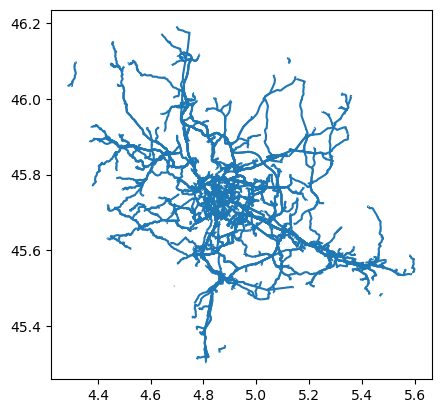

In [43]:
gdf_tomtom = gpd.GeoDataFrame(tomtom_response_list, crs="EPSG:4326")
gdf_tomtom.plot()
gdf_tomtom


In [44]:
df_reference_samples["request_index"] = np.arange(len(df_reference_samples))

# Crete matsim requests
matsim_request_list = []

for index, row in df_reference_samples.iterrows():
    matsim_request_list.append({
        "request_index": int(row["request_index"]),
        "origin_x": row["origin_x"],
        "origin_y": row["origin_y"],
        "destination_x": row["destination_x"],
        "destination_y": row["destination_y"],
        "departure_time_s": matsim_departure_time,
        "consider_parallel_links": True,
        "provide_geometry": True,
    })

In [45]:
# Prepare querying
def query_requests(request_list, settings):
    df_response = []
    batch_index = 0

    while batch_index * matsim_batch_size < len(request_list):
        batch = request_list[batch_index * matsim_batch_size : (batch_index + 1) * matsim_batch_size]

        response = requests.post(matsim_routing_endpoint, verify=False, json = {
            "batch": batch,
            "freeflow": settings
        })

        df_response.append(pd.DataFrame.from_records(response.json()))
        batch_index += 1

    return pd.concat(df_response)

In [46]:
# Define matsim variables
mastim_freeflow_settings = {
    "major_factor": 1.0,
    "intermediate_factor": 1.0,
    "minor_factor": 1.0,
    "major_crossing_penalty_s": 4.0,
    "equal_crossing_penalty_s": 0.0,
    "minor_crossing_penalty_s": 0.0,
}

<Axes: >

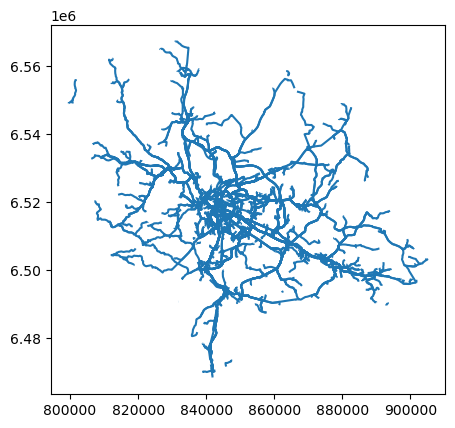

In [47]:
df_mastim_response_list = query_requests(matsim_request_list, mastim_freeflow_settings)
df_mastim_response_list = df_mastim_response_list.merge(
    df_reference_samples[["request_index", "trip_id"]],
    on="request_index",
    how="left"
)
df_mastim_response_list = df_mastim_response_list.dropna(subset=['road_geometry'])
df_mastim_response_list["geometry"] = gpd.GeoSeries.from_wkt(df_mastim_response_list["road_geometry"])
gdf_mastim_response_list = gpd.GeoDataFrame(
    df_mastim_response_list,
    crs="EPSG:2154"
)
gdf_mastim_response_list.plot()

In [48]:
# Plot the results

df_result = df_reference_samples[["trip_id", "reference_travel_time_s"]].copy().rename(columns={"reference_travel_time_s": "reference"})
df_mastim_response_list["total_travel_time_sec"] = df_mastim_response_list["total_travel_time_min"] * 60
df_result = df_result.merge(
    df_tomtom[["trip_id", "travel_time_no_traffic"]].rename(columns={"travel_time_no_traffic": "tomtom"}),
    on="trip_id",
    how="left"
)
df_result = df_result.merge(
    df_mastim_response_list[["trip_id", "total_travel_time_sec"]].rename(columns={"total_travel_time_sec": "matsim"}),
    on="trip_id",
    how="left"
)
df_result = df_result.astype({
    "trip_id": str,
})

display(df_result)

fig = px.bar(
    df_result.melt(id_vars="trip_id", value_vars=["reference", "tomtom", "matsim"]),
    x="trip_id",
    y="value",
    color="variable",
    barmode="group",
    title="Travel time comparison",
    labels={"value": "Travel time (s)", "variable": "Source", "trip_id": "Trip"},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(
    xaxis_title="Trip",
    yaxis_title="Travel time (s)",
    legend_title_text="Source"
)
fig.show()

fig_ref_vs_matsim = px.scatter(
    df_result,
    x="reference",
    y="matsim",
    labels={"reference": "Reference travel time (s)", "matsim": "MATSim travel time (s)"},
    title="MATSim vs Reference Travel Time"
)
fig_ref_vs_matsim.add_shape(
    type="line",
    x0=df_result["reference"].min(), y0=df_result["reference"].min(),
    x1=df_result["reference"].max(), y1=df_result["reference"].max(),
    line=dict(color="red", dash="dash"),
)
fig_ref_vs_matsim.show()

fig_ref_vs_tomtom = px.scatter(
    df_result,
    x="reference",
    y="tomtom",
    labels={"reference": "Reference travel time (s)", "tomtom": "TomTom travel time (s)"},
    title="TomTom vs Reference Travel Time"
)
fig_ref_vs_tomtom.add_shape(
    type="line",
    x0=df_result["reference"].min(), y0=df_result["reference"].min(),
    x1=df_result["reference"].max(), y1=df_result["reference"].max(),
    line=dict(color="red", dash="dash"),
)
fig_ref_vs_tomtom.show()


fig_matsim_vs_tomtom = px.scatter(
    df_result,
    x="matsim",
    y="tomtom",
    labels={"matsim": "MATSim travel time (s)", "tomtom": "TomTom travel time (s)"},
    title="MATSim vs Tomtom Travel Time"
)
fig_matsim_vs_tomtom.add_shape(
    type="line",
    x0=df_result["matsim"].min(), y0=df_result["matsim"].min(),
    x1=df_result["matsim"].max(), y1=df_result["matsim"].max(),
    line=dict(color="red", dash="dash"),
)
fig_matsim_vs_tomtom.show()

,trip_id,reference,tomtom,matsim
0,291,1800.0,1476.0,1415.390968
1,649,1500.0,1415.0,1373.368465
2,1993,2100.0,808.0,612.303374
3,2432,900.0,678.0,364.625765
4,2439,900.0,648.0,286.483822
...,...,...,...,...
555,97998,720.0,670.0,675.148755
556,98091,1500.0,1560.0,1795.373395
557,98499,600.0,887.0,745.236185
558,98504,300.0,560.0,737.789976


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Plot the results

df_result = df_reference_samples[["trip_id", "reference_travel_time_s", "distance_error"]].copy().rename(columns={"reference_travel_time_s": "reference"})
df_mastim_response_list["total_travel_time_sec"] = df_mastim_response_list["total_travel_time_min"] * 60
df_result = df_result.merge(
    df_tomtom[["trip_id", "travel_time_no_traffic"]].rename(columns={"travel_time_no_traffic": "tomtom"}),
    on="trip_id",
    how="left"
)
df_result = df_result.merge(
    df_mastim_response_list[["trip_id", "total_travel_time_sec"]].rename(columns={"total_travel_time_sec": "matsim"}),
    on="trip_id",
    how="left"
)
df_result = df_result.astype({
    "trip_id": str,
})
df_result["matsim_time_error"] = df_result["matsim"] - df_result["reference"]
df_result["tomtom_time_error"] = df_result["tomtom"] - df_result["reference"]

df_result = df_result.dropna()

fig_error = px.scatter(
    df_result,
    x="distance_error",
    y=["matsim_time_error", "tomtom_time_error"],
    labels={
        "distance_error": "Distance Error (m)",
        "value": "Travel Time Error (s)",
        "variable": "Source"
    },
    title="Travel Time Error vs Distance Error",
)
fig_error.update_traces(marker=dict(size=8))
fig_error.show()


# Prepare data for regression
X = df_result["distance_error"].values.reshape(-1, 1)

# Matsim time error regression
y_matsim = df_result["matsim_time_error"].values
reg_matsim = LinearRegression().fit(X, y_matsim)
y_matsim_pred = reg_matsim.predict(X)
r2_matsim = r2_score(y_matsim, y_matsim_pred)

# Tomtom time error regression
y_tomtom = df_result["tomtom_time_error"].values
reg_tomtom = LinearRegression().fit(X, y_tomtom)
y_tomtom_pred = reg_tomtom.predict(X)
r2_tomtom = r2_score(y_tomtom, y_tomtom_pred)

# Add regression lines to plot
fig_error.add_traces([
    px.line(
        x=df_result["distance_error"],
        y=y_matsim_pred,
        labels={"x": "Distance Error (m)", "y": "Matsim Time Error (s)"},
        title=f"Matsim Regression (R²={r2_matsim:.2f})"
    ).data[0],
    px.line(
        x=df_result["distance_error"],
        y=y_tomtom_pred,
        labels={"x": "Distance Error (m)", "y": "TomTom Time Error (s)"},
        title=f"TomTom Regression (R²={r2_tomtom:.2f})"
    ).data[0]
])

fig_error.update_layout(
    annotations=[
        dict(
            x=0.95, y=0.95, xref="paper", yref="paper",
            text=f"Matsim R²={r2_matsim:.2f}<br>TomTom R²={r2_tomtom:.2f}",
            showarrow=False, align="right", bgcolor="white"
        )
    ]
)
fig_error.show()


In [ ]:
gdf_tomtom.to_file("../../../results/road/freeflow/test_tomtom_routes.geojson", driver="GeoJSON")
gdf_reference_samples.to_file("../../../results/road/freeflow/test_reference_routes.geojson", driver="GeoJSON")
gdf_mastim_response_list.to_file("../../../results/road/freeflow/test_matsim_routes.geojson", driver="GeoJSON")
